In [1]:
%pip install holidays

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
folder_path = 'case_study'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"Found {len(all_files)} CSV files to merge.")

Found 12 CSV files to merge.


In [4]:
df_list = []
for file in all_files:
    print(f"Reading: {os.path.basename(file)}")
    # Reading files one by one
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

Reading: 202412-divvy-tripdata.csv
Reading: 202501-divvy-tripdata.csv
Reading: 202502-divvy-tripdata.csv
Reading: 202503-divvy-tripdata.csv
Reading: 202504-divvy-tripdata.csv
Reading: 202505-divvy-tripdata.csv
Reading: 202506-divvy-tripdata.csv
Reading: 202507-divvy-tripdata.csv
Reading: 202508-divvy-tripdata.csv
Reading: 202509-divvy-tripdata.csv
Reading: 202510-divvy-tripdata.csv
Reading: 202511-divvy-tripdata.csv


In [5]:
print("Merging all files together...")
merged_df = pd.concat(df_list, axis=0, ignore_index=True)

Merging all files together...


In [6]:
print("--- DATASET SHAPE ---")
print(f"Total Rows: {merged_df.shape[0]:,}")
print(f"Total Columns: {merged_df.shape[1]}")

--- DATASET SHAPE ---
Total Rows: 5,590,832
Total Columns: 13


In [7]:
print("\n--- HEADERS & DATA TYPES ---")
print(merged_df.dtypes)


--- HEADERS & DATA TYPES ---
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


In [8]:
merged_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,6C960DEB4F78854E,electric_bike,2024-12-31 01:38:35.018,2024-12-31 01:48:45.775,Halsted St & Roscoe St,TA1309000025,Clark St & Winnemac Ave,TA1309000035,41.943632,-87.649083,41.973348,-87.667855,member
1,C0913EEB2834E7A2,classic_bike,2024-12-21 18:41:26.478,2024-12-21 18:47:33.871,Clark St & Wellington Ave,TA1307000136,Halsted St & Roscoe St,TA1309000025,41.936497,-87.647539,41.943632,-87.649083,member
2,848A37DD4723078A,classic_bike,2024-12-21 11:41:01.664,2024-12-21 11:52:45.094,Sheridan Rd & Montrose Ave,TA1307000107,Broadway & Barry Ave,13137,41.961670,-87.654640,41.937582,-87.644098,member
3,3FA09C762ECB48BD,electric_bike,2024-12-26 13:07:27.526,2024-12-26 13:10:54.130,Aberdeen St & Jackson Blvd,13157,Green St & Randolph St*,chargingstx3,41.877726,-87.654787,41.883602,-87.648627,member
4,E60317ADD1A87488,electric_bike,2024-12-13 15:17:55.063,2024-12-13 15:27:32.583,Paulina St & Flournoy St,KA1504000104,Fairfield Ave & Roosevelt Rd,KA1504000102,41.873061,-87.669135,41.866624,-87.694521,member


In [9]:
total_duplicates = merged_df.duplicated(subset=['ride_id']).sum()
print(f"Number of duplicate ride IDs found: {total_duplicates:,}")

Number of duplicate ride IDs found: 0


In [10]:
print("--- MISSING VALUES PER COLUMN ---")
null_counts = merged_df.isnull().sum()
print(null_counts[null_counts > 0]) # Shows only columns that actually have missing data

--- MISSING VALUES PER COLUMN ---
start_station_name    1186938
start_station_id      1186938
end_station_name      1244036
end_station_id        1244036
end_lat                  5544
end_lng                  5544
dtype: int64


In [11]:
merged_df['start_station_name'] = merged_df['start_station_name'].fillna('Unspecified Station')
merged_df['end_station_name'] = merged_df['end_station_name'].fillna('Unspecified Station')
merged_df['start_station_id'] = merged_df['start_station_id'].fillna('Unspecified Station ID')
merged_df['end_station_id'] = merged_df['end_station_id'].fillna('Unspecified Station ID')

print("\nMissing station names successfully filled with placeholders.")


Missing station names successfully filled with placeholders.


In [12]:
merged_df['started_at'] = pd.to_datetime(merged_df['started_at'])
merged_df['ended_at'] = pd.to_datetime(merged_df['ended_at'])

In [13]:
# 1. Append the trip duration column (in minutes)
merged_df['ride_length_mins'] = (merged_df['ended_at'] - merged_df['started_at']).dt.total_seconds() / 60

# 2. Append the day of the week column (as text string names, e.g., 'Monday')
merged_df['day_of_week'] = merged_df['started_at'].dt.day_name()

merged_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length_mins,day_of_week
0,6C960DEB4F78854E,electric_bike,2024-12-31 01:38:35.018,2024-12-31 01:48:45.775,Halsted St & Roscoe St,TA1309000025,Clark St & Winnemac Ave,TA1309000035,41.943632,-87.649083,41.973348,-87.667855,member,10.179283,Tuesday
1,C0913EEB2834E7A2,classic_bike,2024-12-21 18:41:26.478,2024-12-21 18:47:33.871,Clark St & Wellington Ave,TA1307000136,Halsted St & Roscoe St,TA1309000025,41.936497,-87.647539,41.943632,-87.649083,member,6.123217,Saturday
2,848A37DD4723078A,classic_bike,2024-12-21 11:41:01.664,2024-12-21 11:52:45.094,Sheridan Rd & Montrose Ave,TA1307000107,Broadway & Barry Ave,13137,41.961670,-87.654640,41.937582,-87.644098,member,11.723833,Saturday
3,3FA09C762ECB48BD,electric_bike,2024-12-26 13:07:27.526,2024-12-26 13:10:54.130,Aberdeen St & Jackson Blvd,13157,Green St & Randolph St*,chargingstx3,41.877726,-87.654787,41.883602,-87.648627,member,3.443400,Thursday
4,E60317ADD1A87488,electric_bike,2024-12-13 15:17:55.063,2024-12-13 15:27:32.583,Paulina St & Flournoy St,KA1504000104,Fairfield Ave & Roosevelt Rd,KA1504000102,41.873061,-87.669135,41.866624,-87.694521,member,9.625333,Friday


In [14]:
merged_df['ride_length_mins'].head()

0    10.179283
1     6.123217
2    11.723833
3     3.443400
4     9.625333
Name: ride_length_mins, dtype: float64

In [15]:
# 1. Total starting records
total_initial = len(merged_df)

# 2. Count trips with negative durations (system clock/logging errors)
negative_trips = len(merged_df[merged_df['ride_length_mins'] < 0])

# 3. Count false starts (trips lasting between 0 seconds and 59.99 seconds)
false_starts = len(merged_df[(merged_df['ride_length_mins'] >= 0) & (merged_df['ride_length_mins'] < 1.0)])

# 4. Count ultra-long trips (over 24 hours / 1,440 minutes)
ultra_long_trips = len(merged_df[merged_df['ride_length_mins'] > 1440])

# 5. Count valid trips (what will remain)
valid_trips = len(merged_df[(merged_df['ride_length_mins'] >= 1.0) & (merged_df['ride_length_mins'] <= 1440)])

# Print the pre-cleaning report
print("--- PRE-FILTERING ANOMALY REPORT ---")
print(f"Total Initial Rows:                  {total_initial:,}")
print(f"1. Negative Durations (< 0 mins):    {negative_trips:,}")
print(f"2. False Starts (0 to < 1 min):      {false_starts:,}")
print(f"3. Ultra-Long Trips (> 24 hours):    {ultra_long_trips:,}")
print(f"----------------------------------------")
print(f"Total Valid Trips (To keep):         {valid_trips:,}")

--- PRE-FILTERING ANOMALY REPORT ---
Total Initial Rows:                  5,590,832
1. Negative Durations (< 0 mins):    29
2. False Starts (0 to < 1 min):      146,757
3. Ultra-Long Trips (> 24 hours):    5,601
----------------------------------------
Total Valid Trips (To keep):         5,438,445


In [16]:
# Filter the dataframe to keep only the valid trips
cleaned_df = merged_df[(merged_df['ride_length_mins'] >= 1.0) & (merged_df['ride_length_mins'] <= 1440)].copy()

In [17]:
cleaned_df.head(10)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length_mins,day_of_week
0,6C960DEB4F78854E,electric_bike,2024-12-31 01:38:35.018,2024-12-31 01:48:45.775,Halsted St & Roscoe St,TA1309000025,Clark St & Winnemac Ave,TA1309000035,41.943632,-87.649083,41.973348,-87.667855,member,10.179283,Tuesday
1,C0913EEB2834E7A2,classic_bike,2024-12-21 18:41:26.478,2024-12-21 18:47:33.871,Clark St & Wellington Ave,TA1307000136,Halsted St & Roscoe St,TA1309000025,41.936497,-87.647539,41.943632,-87.649083,member,6.123217,Saturday
2,848A37DD4723078A,classic_bike,2024-12-21 11:41:01.664,2024-12-21 11:52:45.094,Sheridan Rd & Montrose Ave,TA1307000107,Broadway & Barry Ave,13137,41.961670,-87.654640,41.937582,-87.644098,member,11.723833,Saturday
3,3FA09C762ECB48BD,electric_bike,2024-12-26 13:07:27.526,2024-12-26 13:10:54.130,Aberdeen St & Jackson Blvd,13157,Green St & Randolph St*,chargingstx3,41.877726,-87.654787,41.883602,-87.648627,member,3.443400,Thursday
4,E60317ADD1A87488,electric_bike,2024-12-13 15:17:55.063,2024-12-13 15:27:32.583,Paulina St & Flournoy St,KA1504000104,Fairfield Ave & Roosevelt Rd,KA1504000102,41.873061,-87.669135,41.866624,-87.694521,member,9.625333,Friday
5,A83DBA54802B4618,electric_bike,2024-12-08 03:24:46.718,2024-12-08 03:33:21.733,Ravenswood Ave & Lawrence Ave,TA1309000066,Kedzie Ave & Leland Ave,KA1504000126,41.968445,-87.674226,41.966686,-87.708052,member,8.583583,Sunday
6,D3D6DAF0AB53F245,electric_bike,2024-12-08 18:56:35.855,2024-12-08 19:04:09.295,Paulina St & Flournoy St,KA1504000104,Fairfield Ave & Roosevelt Rd,KA1504000102,41.873061,-87.669135,41.866624,-87.694521,member,7.557333,Sunday
7,3309E4E902565E04,electric_bike,2024-12-09 16:26:13.301,2024-12-09 16:33:29.555,Paulina St & Flournoy St,KA1504000104,Fairfield Ave & Roosevelt Rd,KA1504000102,41.873061,-87.669135,41.866624,-87.694521,member,7.270900,Monday
8,805D6F3B51AD91AF,electric_bike,2024-12-19 16:30:17.751,2024-12-19 16:44:23.702,Paulina St & Flournoy St,KA1504000104,Michigan Ave & 18th St,13150,41.873061,-87.669135,41.857926,-87.624336,member,14.099183,Thursday
9,8560580463C7E866,electric_bike,2024-12-21 06:38:40.043,2024-12-21 06:41:35.290,Rockwell St & Archer Ave,21379,Leavitt St & Archer Ave,KA1503000068,41.822720,-87.689820,41.828792,-87.680604,member,2.920783,Saturday


In [18]:

total_rows = len(cleaned_df)
print(f"Total Rows in Dataset: {total_rows:,}\n")

print("--- UNIQUE VALUE COUNT PER COLUMN ---")
for col in cleaned_df.columns:
    unique_count = cleaned_df[col].nunique()
    print(f"{col:<20} : {unique_count:,} unique values")

Total Rows in Dataset: 5,438,445

--- UNIQUE VALUE COUNT PER COLUMN ---
ride_id              : 5,438,445 unique values
rideable_type        : 2 unique values
started_at           : 5,437,436 unique values
ended_at             : 5,436,143 unique values
start_station_name   : 1,857 unique values
start_station_id     : 3,300 unique values
end_station_name     : 1,870 unique values
end_station_id       : 3,326 unique values
start_lat            : 117,507 unique values
start_lng            : 115,747 unique values
end_lat              : 1,985 unique values
end_lng              : 1,983 unique values
member_casual        : 2 unique values
ride_length_mins     : 1,857,790 unique values
day_of_week          : 7 unique values


In [19]:
print("--- BIKE TYPES DISTRIBUTION ---")
print(cleaned_df['rideable_type'].value_counts())

print("\n--- USER TYPES DISTRIBUTION ---")
print(cleaned_df['member_casual'].value_counts())

--- BIKE TYPES DISTRIBUTION ---
rideable_type
electric_bike    3470349
classic_bike     1968096
Name: count, dtype: int64

--- USER TYPES DISTRIBUTION ---
member_casual
member    3512390
casual    1926055
Name: count, dtype: int64


In [20]:
# Calculate basic descriptive trip duration stats grouped by user type
duration_analysis = cleaned_df.groupby('member_casual')['ride_length_mins'].agg(['count', 'mean', 'median', 'max']).reset_index()

print("--- TRIP LENGTH DESCRIPTIVE STATISTICS (MINUTES) ---")
print(duration_analysis)

--- TRIP LENGTH DESCRIPTIVE STATISTICS (MINUTES) ---
  member_casual    count       mean     median          max
0        casual  1926055  19.888086  11.880983  1439.975950
1        member  3512390  12.133933   8.722750  1439.901683


In [21]:
# 1. Group by user type and day of week to see trip volume distribution
weekly_volume = cleaned_df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='trip_count')

# Pivot the data to make it easier to read
weekly_pivot = weekly_volume.pivot(index='day_of_week', columns='member_casual', values='trip_count')

# Reorder the days so they read chronologically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_pivot = weekly_pivot.reindex(days_order)

print("--- WEEKLY TRIP COUNTS ---")
print(weekly_pivot)

--- WEEKLY TRIP COUNTS ---
member_casual  casual  member
day_of_week                  
Monday         222877  503484
Tuesday        217754  555916
Wednesday      212569  539468
Thursday       248526  566968
Friday         306615  520027
Saturday       396971  442842
Sunday         320743  383685


In [22]:
# Group by user type and bike type preference
bike_preference = cleaned_df.groupby(['member_casual', 'rideable_type']).size().reset_index(name='trip_count')
bike_pivot = bike_preference.pivot(index='rideable_type', columns='member_casual', values='trip_count')

print("\n--- BIKE TYPE PREFERENCES ---")
print(bike_pivot)


--- BIKE TYPE PREFERENCES ---
member_casual   casual   member
rideable_type                  
classic_bike    674080  1294016
electric_bike  1251975  2218374


In [23]:
# Extract the hour of the day from the start time (0 to 23)
cleaned_df['start_hour'] = cleaned_df['started_at'].dt.hour

# Group by user type and hour
hourly_trends = cleaned_df.groupby(['start_hour', 'member_casual']).size().unstack(fill_value=0)

print("\n--- HOURLY TRIP PATTERNS PROFILE (PREVIEW) ---")
print(hourly_trends.head())


--- HOURLY TRIP PATTERNS PROFILE (PREVIEW) ---
member_casual  casual  member
start_hour                   
0               36861   31552
1               23693   19251
2               15752   11501
3                8756    7620
4                6976    8670


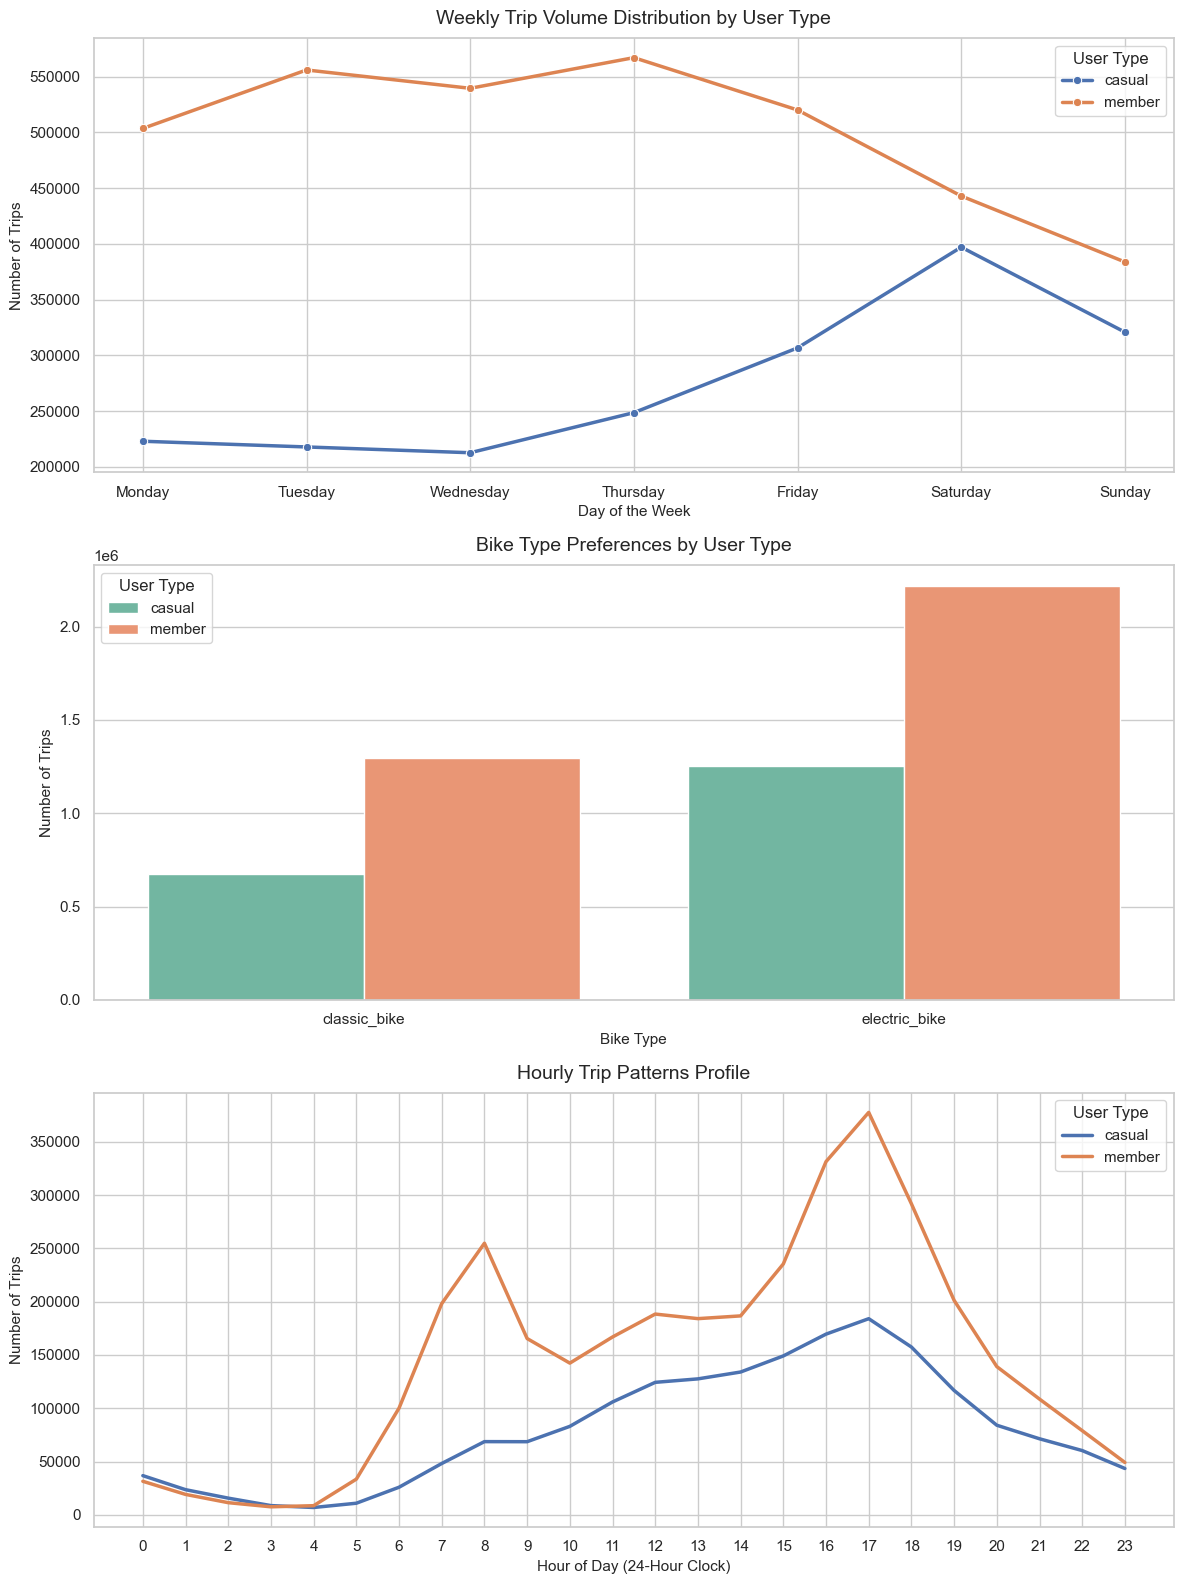

In [24]:


# Set a clean, modern aesthetic for all plots
sns.set_theme(style="whitegrid")

# Create a single figure with 3 subplots arranged vertically
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 16))

# ==========================================
# 1. VISUALIZE WEEKLY TRIP COUNTS (Top Plot)
# ==========================================
# Reshape the weekly pivot table back to long-form for Seaborn
weekly_long = weekly_pivot.reset_index().melt(
    id_vars="day_of_week", 
    value_vars=["casual", "member"], 
    var_name="User Type", 
    value_name="Trips"
)

sns.lineplot(
    data=weekly_long,
    x="day_of_week",
    y="Trips",
    hue="User Type",
    marker="o",
    linewidth=2.5,
    ax=axes[0]  # Assign to the first subplot
)
axes[0].set_title("Weekly Trip Volume Distribution by User Type", fontsize=14, pad=10)
axes[0].set_xlabel("Day of the Week", fontsize=11)
axes[0].set_ylabel("Number of Trips", fontsize=11)
axes[0].legend(title="User Type")

# ==========================================
# 2. VISUALIZE BIKE TYPE PREFERENCES (Middle Plot)
# ==========================================
# Reshape the bike pivot table back to long-form
bike_long = bike_pivot.reset_index().melt(
    id_vars="rideable_type", 
    value_vars=["casual", "member"], 
    var_name="User Type", 
    value_name="Trips"
)

sns.barplot(
    data=bike_long,
    x="rideable_type",
    y="Trips",
    hue="User Type",
    palette="Set2",
    ax=axes[1]  # Assign to the second subplot
)
axes[1].set_title("Bike Type Preferences by User Type", fontsize=14, pad=10)
axes[1].set_xlabel("Bike Type", fontsize=11)
axes[1].set_ylabel("Number of Trips", fontsize=11)
axes[1].legend(title="User Type")

# ==========================================
# 3. VISUALIZE HOURLY TRIP PATTERNS (Bottom Plot)
# ==========================================
# Reshape the hourly trends profile back to long-form
hourly_long = hourly_trends.reset_index().melt(
    id_vars="start_hour", 
    value_vars=["casual", "member"], 
    var_name="User Type", 
    value_name="Trips"
)

sns.lineplot(
    data=hourly_long,
    x="start_hour",
    y="Trips",
    hue="User Type",
    linewidth=2.5,
    ax=axes[2]  # Assign to the third subplot
)
axes[2].set_title("Hourly Trip Patterns Profile", fontsize=14, pad=10)
axes[2].set_xlabel("Hour of Day (24-Hour Clock)", fontsize=11)
axes[2].set_ylabel("Number of Trips", fontsize=11)
axes[2].set_xticks(range(0, 24))  # Ensure every hour label is shown
axes[2].legend(title="User Type")

# Automatically adjust spacing between plots to prevent labels from overlapping
plt.tight_layout()

# Save the complete dashboard grid as an image file
plt.savefig("trip_analysis_dashboard.png", dpi=300)

In [25]:

cleaned_df['started_at'] = pd.to_datetime(cleaned_df['started_at'])

# 2. Extract the hour component
cleaned_df['hour'] = cleaned_df['started_at'].dt.hour

# 3. Classify each hour as AM or PM
cleaned_df['time_period'] = cleaned_df['hour'].apply(lambda x: 'AM' if x < 12 else 'PM')

# 4. Group by user type and time period
ampm_analysis = cleaned_df.groupby(['member_casual', 'time_period']).size().unstack(fill_value=0)

ampm_pct = ampm_analysis.div(ampm_analysis.sum(axis=1), axis=0) * 100

print("--- AM / PM TRIP VOLUMES ---")
print(ampm_analysis)
print("\n--- AM / PM PERCENTAGE DISTRIBUTION ---")
print(ampm_pct.round(2).astype(str) + '%')

--- AM / PM TRIP VOLUMES ---
time_period         AM       PM
member_casual                  
casual          503684  1422371
member         1140022  2372368

--- AM / PM PERCENTAGE DISTRIBUTION ---
time_period        AM      PM
member_casual                
casual         26.15%  73.85%
member         32.46%  67.54%


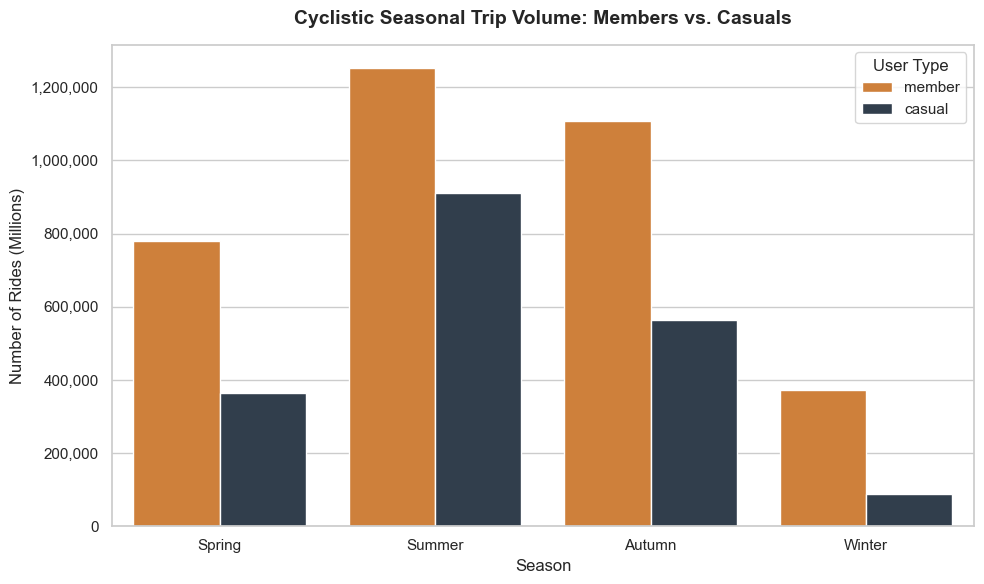

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map months to seasons
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

cleaned_df['month'] = cleaned_df['started_at'].dt.month
cleaned_df['season'] = cleaned_df['month'].apply(get_season)

# 2. Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create a grouped bar chart
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
ax = sns.countplot(
    data=cleaned_df, 
    x='season', 
    hue='member_casual', 
    order=season_order, 
    palette=['#e67e22', '#2c3e50'] # Warm orange for casuals, sleek navy for members
)

# 4. Format the chart
plt.title('Cyclistic Seasonal Trip Volume: Members vs. Casuals', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Rides (Millions)', fontsize=12)
plt.legend(title='User Type')

# Clean up y-axis readability
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

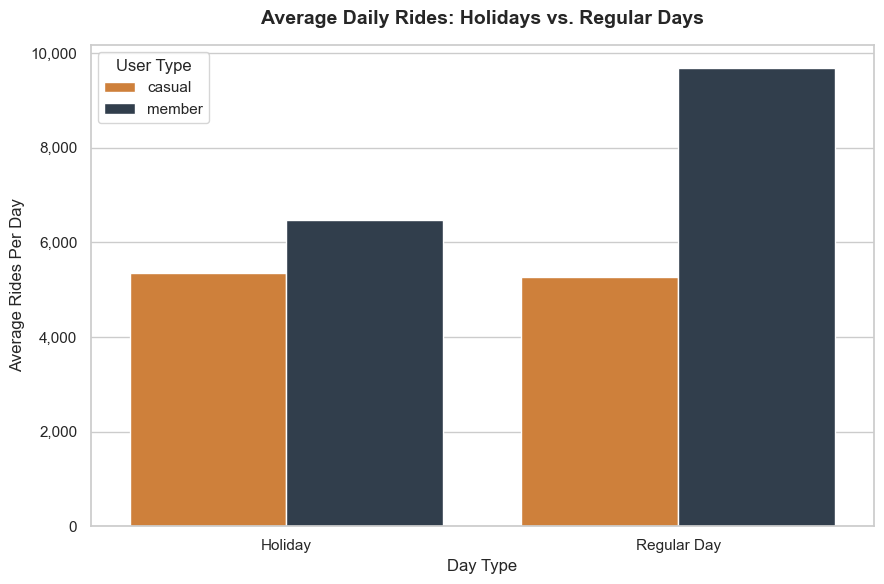

In [27]:

import holidays

# 1. Get US federal holidays for the year matching the data
us_holidays = holidays.US(years=cleaned_df['started_at'].dt.year.unique().tolist())

# 2. Extract just the date and map it
cleaned_df['date'] = cleaned_df['started_at'].dt.date
cleaned_df['is_holiday'] = cleaned_df['date'].apply(lambda x: 'Holiday' if x in us_holidays else 'Regular Day')

# 3. Let's compare the average daily ride volume on holidays vs regular days
daily_rides = cleaned_df.groupby(['date', 'member_casual', 'is_holiday']).size().reset_index(name='daily_volume')
avg_daily_rides = daily_rides.groupby(['is_holiday', 'member_casual'])['daily_volume'].mean().reset_index()

# 4. Plot the Holiday Behavior
plt.figure(figsize=(9, 6))
ax2 = sns.barplot(
    data=avg_daily_rides, 
    x='is_holiday', 
    y='daily_volume', 
    hue='member_casual', 
    palette=['#e67e22', '#2c3e50']
)

plt.title('Average Daily Rides: Holidays vs. Regular Days', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Average Rides Per Day', fontsize=12)
plt.legend(title='User Type')
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

In [29]:

cleaned_df.to_csv('cleaned_case_study_trip_data.csv', index=False)
print("DataFrame saved successfully as 'cleaned_case_study_trip_data.csv'!")

DataFrame saved successfully as 'cleaned_case_study_trip_data.csv'!
